In [1]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('credit_card_transactions.csv')  # Replace 'your_dataset.csv' with your actual file name

# Display the first few rows
print(df.head())

# Get information about the dataset
print(df.info())

# Check for missing values
print(df.isnull().sum())

# Statistical summary
print(df.describe())

   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2019-01-01 00:00:18  2703186189652095   
1           1   2019-01-01 00:00:44      630423337322   
2           2   2019-01-01 00:00:51    38859492057661   
3           3   2019-01-01 00:01:16  3534093764340240   
4           4   2019-01-01 00:03:06   375534208663984   

                             merchant       category     amt      first  \
0          fraud_Rippin, Kub and Mann       misc_net    4.97   Jennifer   
1     fraud_Heller, Gutmann and Zieme    grocery_pos  107.23  Stephanie   
2                fraud_Lind-Buckridge  entertainment  220.11     Edward   
3  fraud_Kutch, Hermiston and Farrell  gas_transport   45.00     Jeremy   
4                 fraud_Keeling-Crist       misc_pos   41.96      Tyler   

      last gender                        street  ...      long city_pop  \
0    Banks      F                561 Perry Cove  ...  -81.1781     3495   
1     Gill      F  43039 Riley Greens Suite 393  ... -11

gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97543
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
misc_pos           79655
misc_net           63287
grocery_net        45452
travel             40507
Name: category, dtype: int64
fraud_Kilback LLC                       4403
fraud_Cormier LLC                       3649
fraud_Schumm PLC                        3634
fraud_Kuhn LLC                          3510
fraud_Boyer PLC                         3493
                                        ... 
fraud_Treutel-King                       775
fraud_Douglas, DuBuque and McKenzie      775
fraud_Medhurst, Labadie and Gottlieb     759
fraud_Reichert-Weissnat                  753
fraud_Hahn, Douglas and Schowalter       727
Name: merchant, Length: 693, dtype: int64


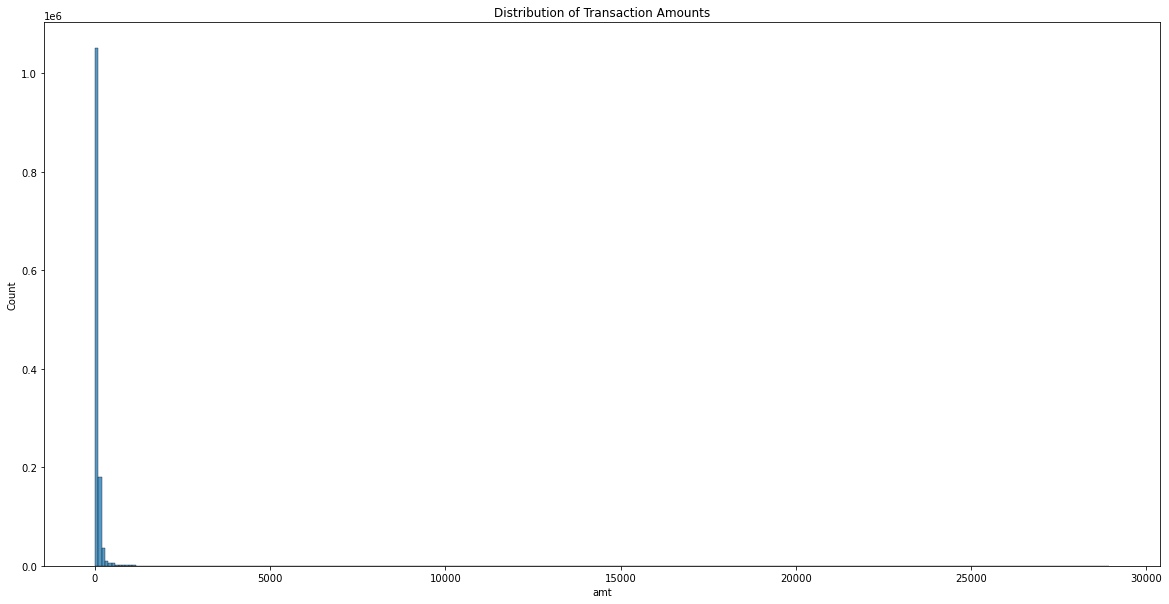

In [2]:
# Convert 'trans_date_trans_time' to datetime format
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Handle missing values in 'merch_zipcode'
# You could impute with a specific value, mode, or a predictive model.
# For now, let's fill with a placeholder:
df['merch_zipcode'].fillna('Missing', inplace=True)

# Feature Engineering
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month
df['year'] = df['trans_date_trans_time'].dt.year

# Explore categorical variables
print(df['category'].value_counts())
print(df['merchant'].value_counts())

# Explore numerical variables
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 10))
sns.histplot(df['amt'], bins=300)
plt.title('Distribution of Transaction Amounts')
plt.show()

In [3]:
# from sklearn.preprocessing import LabelEncoder

# # Target encode 'merchant' and 'category'
# for col in ['merchant', 'category']:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col])
#     df[col] = df.groupby(col)['is_fraud'].transform('mean')
    
# print(le)

In [4]:
pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [5]:
from category_encoders import TargetEncoder

target_encoder = TargetEncoder()
df['merchant_encoded'] = target_encoder.fit_transform(df['merchant'], df['is_fraud'])
df['category_encoded'] = target_encoder.fit_transform(df['category'], df['is_fraud'])

In [6]:
pip install geopy

Note: you may need to restart the kernel to use updated packages.


In [7]:
from geopy.distance import geodesic

def calculate_distance(row):
    customer_coords = (row['lat'], row['long'])
    merchant_coords = (row['merch_lat'], row['merch_long'])
    return geodesic(customer_coords, merchant_coords).km

df['distance'] = df.apply(calculate_distance, axis=1)

# Categorize distance into bins:
bins = [0, 10, 50, 100, np.inf]
labels = ['very_close', 'close', 'far', 'very_far']
df['distance_category'] = pd.cut(df['distance'], bins=bins, labels=labels)

In [8]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,is_fraud,merch_zipcode,hour,day,month,year,merchant_encoded,category_encoded,distance,distance_category
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,0,28705.0,0,1,1,2019,0.014207,0.014458,78.773821,far
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,0,Missing,0,1,1,2019,0.010787,0.014098,30.216618,close
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,0,83236.0,0,1,1,2019,0.002111,0.002478,108.102912,very_far
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,0,Missing,0,1,1,2019,0.003444,0.004694,95.685115,far
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,0,22844.0,0,1,1,2019,0.003769,0.003139,77.702395,far


In [9]:
# Calculate the correlation coefficient
correlation = df['distance'].corr(df['is_fraud'])
print("Correlation coefficient:", correlation)

Correlation coefficient: 0.00040404905896244074


In [10]:
print(df['distance_category'].value_counts())

far           729384
very_far      302292
close         254445
very_close     10554
Name: distance_category, dtype: int64


In [34]:
import pandas as pd

# Filter for fraudulent transactions
fraud_df = df[df['is_fraud'] == 1]

# Group by distance category and count fraudulent transactions
fraud_by_distance_category = fraud_df.groupby('distance_category').size()

print(fraud_by_distance_category)

distance_category
very_close      54
close         1432
far           4274
very_far      1746
dtype: int64


In [11]:
import re

def assign_card_type(cc_num):
    cc_num_str = str(cc_num)
    if re.match(r'^4\d{15}$', cc_num_str):
        return 'Visa'
    elif re.match(r'^5[1-5]\d{14}$', cc_num_str):
        return 'Mastercard'
    elif re.match(r'^3[47]\d{13}$', cc_num_str):
        return 'American Express'
    else:
        return 'Unknown'

df['card_type'] = df['cc_num'].apply(assign_card_type)

In [14]:
print(df['card_type'].value_counts())

Unknown             941423
Visa                210830
American Express    123834
Mastercard           20588
Name: card_type, dtype: int64


In [18]:
import pandas as pd

# Filter for fraudulent transactions
fraud_df = df[df['is_fraud'] == 1]

# Group the filtered DataFrame by card type and count the occurrences
fraud_count_by_card_type = fraud_df.groupby('card_type').size()

print(fraud_count_by_card_type)

card_type
American Express     626
Mastercard           162
Unknown             5525
Visa                1193
dtype: int64


In [33]:
# Check for unusual digit counts
df['cc_num_length'] = df['cc_num'].astype(str).str.len()
print(df['cc_num_length'].value_counts())

# Filter for cards with unusual lengths (e.g., less than 16 digits)
unusual_cards = df[df['cc_num_length'] < 16]
# print(unusual_cards)

16    649148
15    215968
14    125985
19    118789
12     91468
13     89206
11      6111
Name: cc_num_length, dtype: int64


In [20]:
def identify_unusual_cards(row):
    if row['card_type'] == 'American Express':
        return row['cc_num_length'] < 15
    else:
        return row['cc_num_length'] < 16

df['unusual_length'] = df.apply(identify_unusual_cards, axis=1)

In [21]:
def preprocess_card_number(cc_num, card_type):
    if card_type == 'Mastercard' and len(str(cc_num)) < 15:
        return str(cc_num).zfill(15)
    elif len(str(cc_num)) < 16:
        return str(cc_num).zfill(16)
    else:
        return cc_num

df['preprocessed_cc_num'] = df.apply(lambda row: preprocess_card_number(row['cc_num'], row['card_type']), axis=1)

In [29]:
# Extract length during preprocessing
df['preprocessed_cc_num_length'] = df['preprocessed_cc_num'].str.len()

In [30]:
print(df['preprocessed_cc_num_length'].value_counts())

16.0    528738
Name: preprocessed_cc_num_length, dtype: int64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the boxplot using seaborn
sns.boxplot(data=df[['cc_num_length']], x='cc_num_length')

# Show the plot
plt.show()

In [ ]:
def group_categories(category):
    if category in ['gas_transport', 'travel']:
        return 'Transportation'
    elif category in ['grocery_pos', 'grocery_net', 'food_dining', 'kids_pets', 'personal_care', 'health_fitness']:
        return 'Essentials'
    elif category in ['shopping_pos', 'shopping_net', 'home', 'misc_pos', 'misc_net']:
        return 'Shopping'
    elif category == 'entertainment':
        return 'Entertainment'
    else:
        return 'Other'

df['category_grouped'] = df['category'].apply(group_categories)

In [31]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,year,merchant_encoded,category_encoded,distance,distance_category,card_type,cc_num_length,unusual_length,preprocessed_cc_num,preprocessed_cc_num_length
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,2019,0.014207,0.014458,78.773821,far,Unknown,16,False,2703186189652095,NaN
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,2019,0.010787,0.014098,30.216618,close,Unknown,12,True,0000630423337322,16.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,2019,0.002111,0.002478,108.102912,very_far,Unknown,14,True,0038859492057661,16.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,2019,0.003444,0.004694,95.685115,far,Unknown,16,False,3534093764340240,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,2019,0.003769,0.003139,77.702395,far,American Express,15,False,0375534208663984,16.0


In [ ]:
from sklearn.preprocessing import StandardScaler

# Select the numerical features to be standardized
numerical_features = ['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'distance']

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler to the numerical features and transform the data
df[numerical_features] = scaler.fit_transform(df[numerical_features])

In [ ]:
df.head()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Matrix
correlation_matrix = df.corr()

# Increase figure size (adjust width and height as needed)
plt.figure(figsize=(20, 10))  # Here, width is 10 and height is 6

# Create the heatmap with annotations set to False
sns.heatmap(correlation_matrix, annot=True)

# Title and display
plt.title('Correlation Matrix')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ... (your data loading and preprocessing code)

# Calculate correlation matrix
corr_matrix = df.corr()

# Select highly correlated features
correlated_features = corr_matrix['is_fraud'].sort_values(ascending=False)
correlated_features = correlated_features[correlated_features > 0.2]

# Select features based on correlation
selected_features = correlated_features.index.tolist()

# Create a new DataFrame with selected features
X = df[selected_features]
y = df['is_fraud']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
correlated_features